In [35]:
from matplotlib import pyplot as plt
import numpy as np
import seaborn as sns
from pathlib import Path
import json
from types import SimpleNamespace
import pandas as pd
import scipy.stats as st
import itertools
from matplotlib import gridspec


sns.set(font_scale=1.2, style='ticks', font='Helvetica Neue')

In [2]:
git_folder = Path('../..')
code_folder = git_folder / 'code' / '7_CRM'
results_folder = git_folder / 'simulation_results' / 'cs_sweep'
figure_folder = git_folder / 'figures' / '7_CRM'
figure_folder.mkdir(parents=True, exist_ok=True)


run = '20251219-000823'
fn_abundances = f'{run}_data.npz'
data = np.load(results_folder / fn_abundances)

fn_args = f'{run}_args.txt'

with open(results_folder / fn_args, 'r') as f:
    args_dict = json.load(f)
args = SimpleNamespace(**args_dict)




In [3]:
parsed_data = []

n_cs_arr = data['cs_arr'] 
K_std_arr = data['Kstd_arr'] 
csp_arr = data['csp_arr']
for i in range(args.N):
    N = data[f'N_final_{i}']
    C = data[f'C_{i}']
    n_cs = n_cs_arr[i]
    K_std = K_std_arr[i]
    csp = csp_arr[i]
    
    for j in range(args.iterations):
        richness = np.sum(N[:, j] > 1e-6)
        abundance = list(N[:, j])
        parsed_data.append([i, j, n_cs, K_std, csp, richness]+ abundance)

In [4]:
df = pd.DataFrame(parsed_data, columns = ['i', 'cs_j', 'n_cs', 'K_std', 'csp', 'richness', 'N1', 'N2', 'N3', 'N4'])

In [5]:
# Assume df has columns: ['i', 'cs_j', 'richness']

# For each group (e.g., by 'i'), compute the conditional probability
pivot = df.pivot_table(index='i', columns='cs_j', values='richness', aggfunc='mean')
results = []
for cs_j in range(1, 7):
    for richness in range(5):
        mask_n0 = (pivot.loc[:, :cs_j-1] == richness).all(axis=1)
        mask_n = (pivot.loc[mask_n0, cs_j] == richness)
        # gdf = df.loc[mask_n0].groupby('i').mean().reset_index()
        # # idxs = gdf.loc[gdf.richness == richness, 'i'].values
        # mask_n = (df['cs_j'] == cs_j) & (df['richness'] == richness)& (df['i'].isin(idxs))
        
        n = mask_n.sum()
        # n_total = len(idxs)
        n_total = mask_n0.sum()
        results.append([cs_j, richness, n, n_total])
        total_n = (df['cs_j'] == cs_j).sum()
        
cond_prob_df = pd.DataFrame(results, columns= ['cs_j', 'richness', 'n', 'n_total'])

In [6]:
cond_prob_df['P'] = cond_prob_df['n'] / cond_prob_df['n_total']

In [7]:
cond_prob_df.loc[cond_prob_df.richness == 4]

,cs_j,richness,n,n_total,P
4,1,4,283,1166,0.242710
9,2,4,121,283,0.427562
14,3,4,50,121,0.413223
19,4,4,18,50,0.360000
24,5,4,9,18,0.500000
29,6,4,7,9,0.777778


In [8]:
agg_df = cond_prob_df.groupby('cs_j').sum()
agg_df['P'] = agg_df['n'] / agg_df['n_total']

In [9]:
agg_df

,richness,n,n_total,P
cs_j,,,,
1,10,3856,10000,0.385600
2,10,1792,3856,0.464730
3,10,869,1792,0.484933
4,10,443,869,0.509781
5,10,231,443,0.521445
6,10,144,231,0.623377


In [10]:


cols = [0, 1, 2, 3, 4, 5, 6]
pivot_arr = pivot[cols].to_numpy()
all_probs = []
all_cols = []
for k, perm in enumerate(itertools.permutations(range(len(cols)))):
    arr = pivot_arr[:, perm]
    # Do first cs for j=1,2,3,4
    probjs = []
    for j in [1,2,3,4]:
        prob_j = (arr[:, 0]==j).sum()/len(arr)
        probjs.append(prob_j)
    all_probs.append([k, np.nan]+probjs)
    all_cols.append(tuple([perm[0]]))
    for i in range(1, len(cols)):
        probs = [k]
        probjs = []
        prev_mask = arr[:, :i].std(axis=1)==0
        if prev_mask.sum() == 0:
            probs.append(np.nan)
        else:
            this_mask = arr[:, :i+1].std(axis=1)==0
            prob = this_mask.sum()/prev_mask.sum()
            probs.append(prob)
        

        for j in [1,2,3,4]:
            prev_mask = (arr[:, :i]==j).all(axis=1)
            if prev_mask.sum() == 0:
                prob_j = np.nan
            else:
                this_mask = (arr[prev_mask, i]==j)#.all(axis=1)
                prob_j = this_mask.sum()/prev_mask.sum()
            probjs.append(prob_j)

        all_cols.append(perm[:i+1])
        all_probs.append(probs+probjs)

    # Optional: break after N for testing
    # if len(all_probs) >= 100:
    #     break

In [11]:
# j_cols = [f'{i}_S{j}' for i in range(0, len(cols)) for j in [1,2,3,4]]

In [12]:
probdf = pd.DataFrame(all_probs, columns=['Permutation', 'Any', 'R1', 'R2', 'R3', 'R4'])

In [13]:
cols_df = pd.DataFrame({'Columns': all_cols})
cols_df["N_CS"] = cols_df['Columns'].apply(len)

In [14]:
probdf2 = pd.merge(probdf, cols_df, left_index=True, right_index=True)

In [15]:
probdf2.drop_duplicates(inplace=True, subset=['Columns'])

In [16]:
probdf2L = probdf2.melt(id_vars=['Permutation', 'Columns', 'N_CS'], value_vars=['Any', 'R1', 'R2', 'R3', 'R4'], var_name='Richness', value_name='Probability')

# Probability

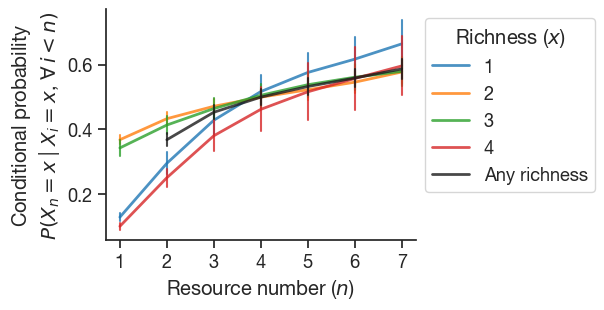

In [17]:
fig, ax = plt.subplots(figsize=(4,3))
colors = sns.color_palette("tab10", n_colors=4)
palette = {'Any': 'k', 'R1': colors[0], 'R2': colors[1], 'R3': colors[2], 'R4': colors[3]}
l = sns.lineplot(probdf2L, x='N_CS', y='Probability', hue='Richness', errorbar='sd', err_style='bars', 
ax = ax, palette=palette, alpha=0.8, lw = 2, hue_order=['R1', 'R2', 'R3', 'R4', 'Any'])  # Move 'Any' to front)



sns.despine()
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
ax.set_xlabel(r'Resource number ($n$)')
ax.set_ylabel(r'Conditional probability$\,$' + '\n' + r'$P(X_n = x$ | $X_i = x$, $\forall \, i < n)$')

new_labels = {
    'Any': 'Any richness',
    'R1': '1',
    'R2': '2',
    'R3': '3',
    'R4': '4'
}
handles, labels = ax.get_legend_handles_labels()
labels = [new_labels.get(label, label) for label in labels]
ax.legend(handles, labels, title="Richness ($x$)", loc="upper left", bbox_to_anchor=(1, 1))
plt.xticks(range(1,8))
plt.savefig(figure_folder / 'cs_screen_conditional_probability.pdf', bbox_inches='tight')


# R1 vs R2

In [42]:
# Plot richness on cs 0 and 1
r1r2_df = df.pivot_table(index='i', columns='cs_j', values='richness')

/Users/snorre/miniconda3/lib/python3.12/site-packages/seaborn/axisgrid.py:1883: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=self.x, ax=self.ax_marg_x, **kwargs)
/Users/snorre/miniconda3/lib/python3.12/site-packages/seaborn/axisgrid.py:1889: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(y=self.y, ax=self.ax_marg_y, **kwargs)


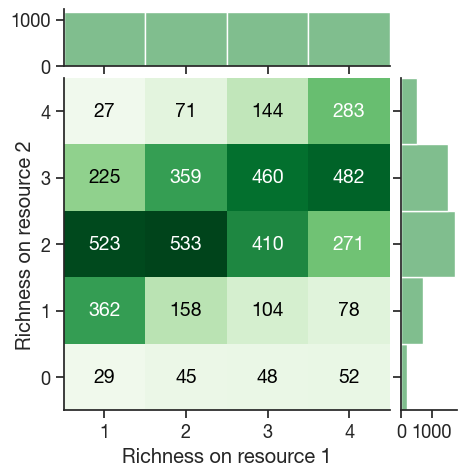

In [321]:
import matplotlib.colors as mcolors
norm = mcolors.BoundaryNorm(boundaries=[0.5, 1.5, 2.5, 3.5], ncolors=4)

# Loop through each species and create a jointplot

r1r2_df_nz = r1r2_df.loc[r1r2_df[0]>0].copy()
n = r1r2_df_nz[0].value_counts().min()
balanced_r1r2 = r1r2_df_nz.groupby(0).sample(n=n, random_state=42)
# Create a jointplot for the current species
# fig = plt.figure(figsize=(5, 5))
g = sns.JointGrid(
    data=balanced_r1r2,
    x=0,
    y=1,
    height = 5
    # fig = fig
)
g.plot_joint(sns.histplot, discrete=(True, True), bins = (5, 4), cmap = 'Greens')  
g.plot_marginals(sns.histplot, palette=palette, fill=True,data=balanced_r1r2, discrete=True, color = f'C{2}')

    
g.ax_joint.set_xlim(0.5, 4.5)
g.ax_joint.set_ylim(-0.5, 4.5)
# g.ax_joint.set_yticks([1, 2, 3, 4])  # Force y-axis ticks to be 1, 2, 3, 4

# Customize the plot
g.ax_joint.set_xlabel('Richness on resource 1')
g.ax_joint.set_ylabel('Richness on resource 2')
g.ax_marg_y.tick_params(labelbottom=True, bottom = True)
# g.ax_marg_y.xaxis.set_major_locator(mticker.MaxNLocator(2))
g.ax_marg_x.tick_params(labelleft=True, left = True)
# hist_data, x_edges, y_edges = np.histogram2d(
#     df_mean78.loc[idx, 'Abundance rank'],
#     df_mean78.loc[idx, 'Predicted rank'],
#     bins=4
# )
heatmap_data = pd.crosstab(balanced_r1r2[0], balanced_r1r2[1]).T
for i in range(1,5):
    for j in range(0,5):
        count = heatmap_data.loc[j, i] if (j in heatmap_data.index and i in heatmap_data.columns) else 0
        if count > 250:
            color = 'w'
        else:
            color = 'black'
        g.ax_joint.text(i, j, count, ha='center', va='center', fontsize=14, color=color, fontdict={'weight': 'regular'})
# # Loop through the bins and annotate
# for i in range(len(x_edges) - 1):
#     for j in range(len(y_edges) - 1):
#         # Compute the center of each bin
#         x = (x_edges[i] + x_edges[i + 1]) / 2
#         y = (y_edges[j] + y_edges[j + 1]) / 2
#         count = int(hist_data[i, j])
#         if count > 0:  # Only annotate non-empty bins
#             g.ax_joint.text(i+1, j+1, count, ha='center', va='center', fontsize=14, color='black', fontdict={'weight': 'regular'})

# plt.savefig(figure_folder / 'predicted_rank_vs_abundance_rank.pdf')
sns.despine()
plt.savefig(figure_folder / 'cs_screen_richness_r1_vs_r2.pdf', bbox_inches='tight')

# C1 vs R1

In [220]:
r1, r2 = 0, 1
r1r2_rich4 = r1r2_df.index[(r1r2_df[[r1,r2]]==4).all(axis=1)]


In [221]:
cs_idx = df.cs_j.isin([r1,r2])
i_idx = df.i.isin(r1r2_rich4)
df_rich4L = df.loc[cs_idx*i_idx].melt(id_vars=['i', 'cs_j'], value_vars=['N1', 'N2', 'N3', 'N4'], var_name='Species', value_name='Abundance')

In [222]:
abu_12_rich4 = df_rich4L.pivot_table(index=['i', 'Species'], columns='cs_j', values='Abundance')

In [223]:
st.pearsonr(np.log10(abu_12_rich4[r1]), np.log10(abu_12_rich4[r2]))

PearsonRResult(statistic=np.float64(-0.0622145214654457), pvalue=np.float64(0.036354904112947735))

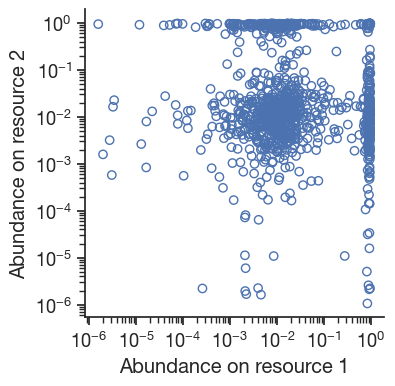

In [347]:
major_locator = mticker.LogLocator(base=10)
minor_locator = mticker.LogLocator(base=10, subs='auto')

fig, ax = plt.subplots(figsize=(4,4))

ax.scatter(abu_12_rich4[r1], abu_12_rich4[r2], marker ='o', facecolors='none', edgecolors='b')

plt.yscale('log')
plt.xscale('log')
plt.xlabel('Abundance on resource 1')
plt.ylabel('Abundance on resource 2')
ax.set_aspect('equal', adjustable='box')

ax.xaxis.set_major_locator(major_locator)
ax.xaxis.set_minor_locator(minor_locator)
ax.yaxis.set_major_locator(major_locator)
ax.yaxis.set_minor_locator(minor_locator)
sns.despine()


In [350]:
abu_12_rich4['Rank r1'] = abu_12_rich4.groupby('i')[r1].rank(ascending=False)
abu_12_rich4['Rank r2'] = abu_12_rich4.groupby('i')[r2].rank(ascending=False)

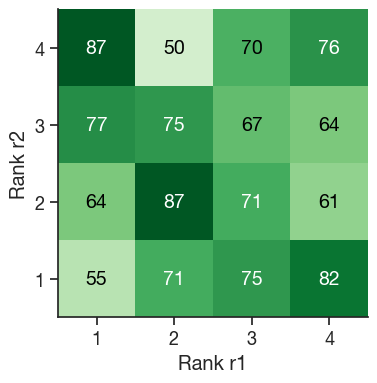

In [356]:
fig, ax = plt.subplots(figsize=(4,4))
sns.histplot(abu_12_rich4, x='Rank r1', y='Rank r2', discrete=(True, True), bins = (4,4), cmap = 'Greens', ax = ax, vmin = 40, vmax = 90)
# Annotate histplot
heatmap_data = pd.crosstab(abu_12_rich4['Rank r1'], abu_12_rich4['Rank r2'])
for i in range(1,5):
    for j in range(1,5):
        count = heatmap_data.loc[i, j]
        if count > 70:
            color = 'w'
        else:
            color = 'black'
        ax.text(i, j, count, ha='center', va='center', fontsize=14, color=color, fontdict={'weight': 'regular'})

ax.set_xlim(0.5, 4.5)
ax.set_ylim(0.5, 4.5)
ax.set_yticks([1, 2, 3, 4])  # Force y-axis ticks to be 1, 2, 3, 4
sns.despine()


# Rank C1 vs Rank abundance on R1

In [307]:

r1 = 0

rich4_r1 = df.loc[(df.richness ==4) & (df.cs_j == r1)]

In [308]:
c_data = []
for i in rich4_r1.i:
    c_i = data[f'C_{i}']
    for j in range(4):
        c_data.append([i, f'N{j+1}', c_i[j, r1]])

In [309]:
c_rich4_df = pd.DataFrame(c_data, columns=['i', 'Species', 'C_r1'])
c_rich4_df['Rank'] = c_rich4_df.groupby('i')['C_r1'].rank(ascending = False)

In [310]:
df_r1_abu = rich4_r1.melt(id_vars = 'i', value_vars=['N1', 'N2', 'N3', 'N4'], var_name = 'Species', value_name='Abundance')
df_r1_abu['Rank'] = df_r1_abu.groupby('i')['Abundance'].rank(ascending=False)
# df.melt?

In [311]:
dfc_r1 = pd.merge(df_r1_abu, right = c_rich4_df, on = ['i', 'Species'])
dfc_r1.rename(columns={'Rank_x': 'Abundance rank on R1', 'Rank_y': 'R1 max uptake rank'}, inplace=True)

In [312]:
# st.pearsonr(dfc_r1.Rank_x, dfc_r1.Rank_y)

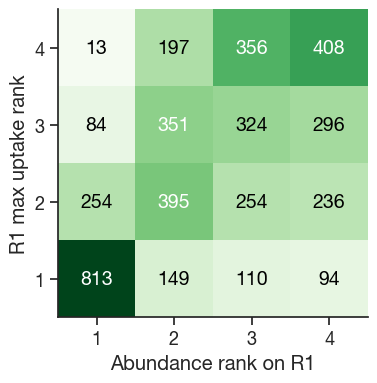

In [313]:
fig, ax = plt.subplots(figsize=(4,4))
sns.histplot(dfc_r1, x='Abundance rank on R1', y='R1 max uptake rank', discrete=(True, True), bins = (4,4), cmap = 'Greens', ax = ax)
# Annotate histplot
heatmap_data = pd.crosstab(dfc_r1['Abundance rank on R1'], dfc_r1['R1 max uptake rank'])
for i in range(1,5):
    for j in range(1,5):
        count = heatmap_data.loc[i, j]
        if count > 350:
            color = 'w'
        else:
            color = 'black'
        ax.text(i, j, count, ha='center', va='center', fontsize=14, color=color, fontdict={'weight': 'regular'})

ax.set_xlim(0.5, 4.5)
ax.set_ylim(0.5, 4.5)
ax.set_yticks([1, 2, 3, 4])  # Force y-axis ticks to be 1, 2, 3, 4
sns.despine()


In [ ]:
abundance_df['R1 rank'] = abundance_df.groupby('index')['R1 abundance'].rank(method='max', ascending=False)

,i,cs_j,n_cs,K_std,csp,richness,N1,N2,N3,N4
0,0,0,29,0.882524,0.296611,2,9.580173e-01,9.999566e-08,9.999100e-08,3.497954e-03
1,0,1,29,0.882524,0.296611,0,9.977147e-08,9.673627e-08,9.680233e-08,9.835428e-08
2,0,2,29,0.882524,0.296611,2,2.315108e-02,9.998414e-08,9.294857e-01,9.999953e-08
3,0,3,29,0.882524,0.296611,0,8.225702e-08,8.225702e-08,8.225702e-08,8.225702e-08
4,0,4,29,0.882524,0.296611,0,9.986111e-08,8.994713e-08,9.574368e-08,9.617509e-08
...,...,...,...,...,...,...,...,...,...,...
69995,9999,2,22,0.754089,0.127819,2,9.308734e-03,9.988179e-08,9.979617e-08,9.752471e-01
69996,9999,3,22,0.754089,0.127819,2,9.076520e-03,9.970750e-08,9.999758e-08,9.683884e-01
69997,9999,4,22,0.754089,0.127819,0,9.832723e-08,9.842228e-08,9.827752e-08,9.982267e-08
69998,9999,5,22,0.754089,0.127819,2,9.820569e-08,9.725085e-01,9.999163e-08,5.444305e-03


In [244]:
# Compute abundance rank for cj1